In [2]:
# Imports to enable plotting functionality
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import bz2
import pickle
import _pickle as cPickle

## Soma functions to enable loading of the pickle files

In [2]:
# Pickle a file and then compress it into a file with extension 
def compressed_pickle(title, data):
    with bz2.BZ2File(title + '.pbz2', 'w') as f: 
        cPickle.dump(data, f)

# Load any compressed pickle file
def decompress_pickle(file):
    data = bz2.BZ2File(file+'.pbz2', 'rb')
    data = cPickle.load(data)
    return data

In [4]:
# Lapicque fitting fcn
def lapique_func(x, a, b):
    return a / (1 - 2**(-x / b))

# Weiss fitting fcn
def weiss_func(x, a, b):
    return a * (1 + (b/x))

# Plot results from Jensen 2005

In [4]:
durations = np.array([0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50])

# Load in anodic data
anodic_data = np.genfromtxt('anodic_data.csv', delimiter=',')[1:10,1]
anodic_data_UB = np.genfromtxt('anodic_data.csv', delimiter=',')[10:19,1]
anodic_data_LB = np.genfromtxt('anodic_data.csv', delimiter=',')[19:28,1]

# Load in cathodic data
cathodic_data = np.genfromtxt('cathodic_data.csv', delimiter=',')[1:10,1]
cathodic_data_UB = np.genfromtxt('cathodic_data.csv', delimiter=',')[10:19,1]
cathodic_data_LB = np.genfromtxt('cathodic_data.csv', delimiter=',')[19:28,1]

# Generate log plot
fig = plt.figure()
fig.set_size_inches(10, 8)
ax = fig.add_subplot(111)

# populate anodic resutls
ax.loglog(durations, anodic_data, marker='v', color='black', 
          markerfacecolor='white', markeredgewidth=2, markersize=8, 
          label='anodal [Jensen 2005]')
ax.errorbar(durations, anodic_data, 
            yerr=[anodic_data-anodic_data_LB, anodic_data_UB-anodic_data], 
            fmt='none', ecolor='black', capsize=7, capthick=2)

# populate cathodic results
ax.loglog(durations, cathodic_data, marker='o', color='black', 
          markerfacecolor='black', markeredgewidth=2, markersize=8, 
          label='cathodal [Jensen 2005]')
ax.errorbar(durations, cathodic_data, 
            yerr=[cathodic_data-cathodic_data_LB, cathodic_data_UB-cathodic_data], 
            fmt='none', ecolor='black', capsize=7, capthick=2)

ax.set_xscale('log', base=10)
ax.set_yscale('log', base=10)
ax.set_xticks([0.1, 1, 10, 100])
ax.set_xticklabels(['0.1', '1', '10', '100'], fontsize=18)
ax.set_xlim([0.05, 100])
ax.set_yticks([0.3, 1, 10])
ax.set_yticklabels(['','1', '10'], fontsize=18)
ax.set_ylim([0.3, 12])
ax.set_ylabel('Threshold current (µA)', fontsize=18)
ax.set_xlabel('Stimulus pulse duration (ms)', fontsize=18)
ax.set_title('Monophasic, 125um electrode', fontsize=20)
ax.legend()


OSError: anodic_data.csv not found.

## Overlay simulated the experimental results

In [15]:
# load in S-D simulated results 
durations = [0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50]
# electrode = [-200, 0, 59]
electrode = [-200, 0, 55]

anodic_sim = []
anodic_sim_35 = []
cathodic_sim = []
cathodic_sim_35 = []

for PW in durations: 
    filename_c = '/Volumes/Scratch/Users/vilkhu/sim-data/strength_duration/monophasic/125um/cathodic_'+\
                str(PW)+'ms_'+\
                str(electrode[0])+'_'+\
                str(electrode[1])+'_'+\
                str(electrode[2])+'.pkl'
    
    filename_c_35 = '/Volumes/Scratch/Users/vilkhu/sim-data/strength_duration/monophasic/125um/35C_cathodic_'+\
                str(PW)+'ms_'+\
                str(electrode[0])+'_'+\
                str(electrode[1])+'_'+\
                str(electrode[2])+'.pkl'

    filename_a = '/Volumes/Scratch/Users/vilkhu/sim-data/strength_duration/monophasic/125um/anodic_'+\
                str(PW)+'ms_'+\
                str(electrode[0])+'_'+\
                str(electrode[1])+'_'+\
                str(electrode[2])+'.pkl'
    
    filename_a_35 = '/Volumes/Scratch/Users/vilkhu/sim-data/strength_duration/monophasic/125um/35C_anodic_'+\
                str(PW)+'ms_'+\
                str(electrode[0])+'_'+\
                str(electrode[1])+'_'+\
                str(electrode[2])+'.pkl'
    
    data_c = decompress_pickle(filename_c)
    data_a = decompress_pickle(filename_a)
    data_a_35 = decompress_pickle(filename_a_35)
    data_c_35 = decompress_pickle(filename_c_35)

    cathodic_sim.append(data_c[0])
    anodic_sim.append(data_a[0])
    anodic_sim_35.append(data_a_35[0])
    cathodic_sim_35.append(data_c_35[0])

In [16]:
print(anodic_sim_35)
print(anodic_sim)

[10.058029063895559, 6.679298743939168, 4.549889238766384, 3.8447796579231968, 3.4641642447370513, 3.113200707676885, 2.7926678425789806, 2.4059961987249707, 1.9880356249900528]
[10.106962097132389, 6.8076029864247865, 4.739242458567882, 4.062604189903507, 3.7007630150960065, 3.3612952141462014, 3.077585944888229, 2.6858235542130124, 2.267279741851828]


In [17]:
print(cathodic_sim_35)
print(cathodic_sim)

[3.752197530391432, 2.1481211783726355, 1.1585450222615021, 0.8163983159064667, 0.6320558044852174, 0.5033287683008333, 0.4514860254913567, 0.4126039683842493, 0.38668259697951096]
[3.772771336509602, 2.174802103936399, 1.1985212418513096, 0.8509991955322549, 0.6769782940238558, 0.5422108254079407, 0.49036808259846415, 0.4514860254913567, 0.4255646540866184]


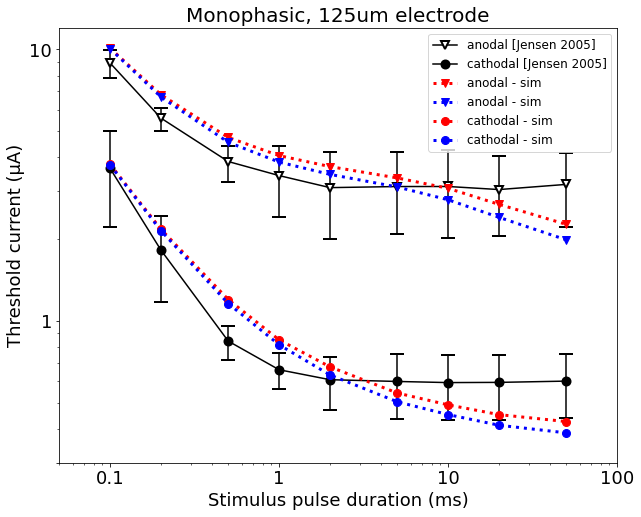

In [18]:
# Generate log plot
fig = plt.figure()
fig.set_size_inches(10, 8)
ax = fig.add_subplot(111)

# populate experimental anodic resutls
ax.loglog(durations, anodic_data, marker='v', color='black', 
          markerfacecolor='white', markeredgewidth=2, markersize=8, 
          label='anodal [Jensen 2005]')
ax.errorbar(durations, anodic_data, 
            yerr=[anodic_data-anodic_data_LB, anodic_data_UB-anodic_data], 
            fmt='none', ecolor='black', capsize=7, capthick=2)

# populate experimental cathodic results
ax.loglog(durations, cathodic_data, marker='o', color='black', 
          markerfacecolor='black', markeredgewidth=2, markersize=8, 
          label='cathodal [Jensen 2005]')
ax.errorbar(durations, cathodic_data, 
            yerr=[cathodic_data-cathodic_data_LB, cathodic_data_UB-cathodic_data], 
            fmt='none', ecolor='black', capsize=7, capthick=2)

# populate simulated anodal and cathodal results
ax.loglog(durations, anodic_sim, 'rv:', markersize=8, linewidth=3, 
          label='anodal - sim')
ax.loglog(durations, anodic_sim_35, 'bv:', markersize=8, linewidth=3, 
          label='anodal - sim')
ax.loglog(durations, cathodic_sim, 'ro:', markersize=8, linewidth=3, 
          label='cathodal - sim')
ax.loglog(durations, cathodic_sim_35, 'bo:', markersize=8, linewidth=3, 
          label='cathodal - sim')

ax.set_xscale('log', base=10)
ax.set_yscale('log', base=10)
ax.set_xticks([0.1, 1, 10, 100])
ax.set_xticklabels(['0.1', '1', '10', '100'], fontsize=18)
ax.set_xlim([0.05, 100])
ax.set_yticks([0.3, 1, 10])
ax.set_yticklabels(['','1', '10'], fontsize=18)
ax.set_ylim([0.3, 12])
ax.set_ylabel('Threshold current (µA)', fontsize=18)
ax.set_xlabel('Stimulus pulse duration (ms)', fontsize=18)
ax.set_title('Monophasic, 125um electrode', fontsize=20)
ax.legend(fontsize=12)

## Below is old code

In [ ]:
### --- fit curve to anodic and cathodic S-D data
x_data = np.asarray(durations)
y_data_anodic = np.asarray(anodic)
y_data_cathodic = np.asarray(cathodic)

# fit lapique func
p0 = np.ones(2)
popt_a, pcov_a = curve_fit(lapique_func, x_data, y_data_anodic, p0=p0)
popt_c, pcov_c = curve_fit(lapique_func, x_data, y_data_cathodic, p0=p0)

x_fit = np.linspace(0.1,50,1000)

y_fit_a = lapique_func(x_fit, *popt_a)
y_fit_c = lapique_func(x_fit, *popt_c)

# fit weiss func
p0 = np.ones(2)
popt_a_w, pcov_a_w = curve_fit(weiss_func, x_data, y_data_anodic, p0=p0)
popt_c_w, pcov_c_w = curve_fit(weiss_func, x_data, y_data_cathodic, p0=p0)

y_fit_a_w = weiss_func(x_fit, *popt_a)
y_fit_c_w = weiss_func(x_fit, *popt_c)

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.loglog(durations, anodic, 'ro-', label='anodic')
ax.loglog(durations, cathodic, 'ko-', label='cathodic')

ax.scatter(durations, anodic, c='r')
ax.scatter(durations, cathodic, c='k')

# ax.plot(x_fit,y_fit_a, alpha=0.8, c='r', label='anodic')
# ax.plot(x_fit,y_fit_c, alpha=0.8, c='k', label='cathodic')

# ax.plot(x_fit,y_fit_a_w, alpha=0.8, label='anodic - weiss', c='r', linestyle='--')
# ax.plot(x_fit,y_fit_c_w, alpha=0.8, label='cathodic -weiss', c='k', linestyle='--')

ax.set_xscale('log', base=10)
ax.set_yscale('log', base=10)
ax.set_xticks([0.1, 1, 10, 100])
ax.set_xticklabels(['0.1', '1', '10', '100'])
ax.set_yticks([0.3, 1, 10])
ax.set_yticklabels(['','1', '10'])
ax.set_ylabel('pulse amplitude (uA)')
ax.set_xlabel('pulse duration (ms)')
ax.set_title('Strength-Duration Curve: Monophasic, 15um')
ax.legend()
ax.grid()

### Output difference at lowest and highest PWs

In [ ]:
print(anodic[0]/cathodic[0])
print(anodic[-1]/cathodic[-1])

### Output chronaxy and rheobase information

In [ ]:
rheobase_c = y_fit_c[-1]
rheobase_a = y_fit_a[-1]
print('Rheobase cathodic: ', rheobase_c)
print('Rheobase anodic: ', rheobase_a)

# find cathodic and anoic chronaxy
idx_chronaxy_c = (np.abs(y_fit_c - 2*rheobase_c)).argmin()
print('Chronaxy cathodic: ', x_fit[idx_chronaxy_c], 'ms')

idx_chronaxy_a = (np.abs(y_fit_a - 2*rheobase_a)).argmin()
print('Chronaxy anodic: ', x_fit[idx_chronaxy_a], 'ms')

## Plot biphasic results

In [ ]:
# load in S-D data pickle files 
durations = [0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1, 2, 3, 5, 8, 10]
electrode = [-1000, 0, 59]

anodic = []
cathodic = []

for dur in durations: 
    filename_c = '../../data/strength_duration/biphasic/15um/cathodic_'+\
                str(dur)+'ms_'+\
                str(electrode[0])+'_'+\
                str(electrode[1])+'_'+\
                str(electrode[2])+'.pkl'

    filename_a = '../../data/strength_duration/biphasic/15um/anodic_'+\
                str(dur)+'ms_'+\
                str(electrode[0])+'_'+\
                str(electrode[1])+'_'+\
                str(electrode[2])+'.pkl'
    
    data_c = decompress_pickle(filename_c)
    data_a = decompress_pickle(filename_a)

    cathodic.append(data_c[0])
    anodic.append(data_a[0])

In [ ]:
### --- fit curve to anodic and cathodic S-D data
x_data = np.asarray(durations)
y_data_anodic = np.asarray(anodic)
y_data_cathodic = np.asarray(cathodic)

# fit lapique func
p0 = np.ones(2)
popt_a, pcov_a = curve_fit(lapique_func, x_data, y_data_anodic, p0=p0)
popt_c, pcov_c = curve_fit(lapique_func, x_data, y_data_cathodic, p0=p0)

x_fit = np.linspace(0.05,10,1000)

y_fit_a = lapique_func(x_fit, *popt_a)
y_fit_c = lapique_func(x_fit, *popt_c)

# fit weiss func
p0 = np.ones(2)
popt_a_w, pcov_a_w = curve_fit(weiss_func, x_data, y_data_anodic, p0=p0)
popt_c_w, pcov_c_w = curve_fit(weiss_func, x_data, y_data_cathodic, p0=p0)

y_fit_a_w = weiss_func(x_fit, *popt_a)
y_fit_c_w = weiss_func(x_fit, *popt_c)

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.loglog(durations, anodic, 'ro-', label='anodic')
ax.loglog(durations, cathodic, 'ko-', label='cathodic')

ax.scatter(durations, anodic, c='r')
ax.scatter(durations, cathodic, c='k')

# ax.plot(x_fit,y_fit_a, alpha=0.8, c='r', label='anodic')
# ax.plot(x_fit,y_fit_c, alpha=0.8, c='k', label='cathodic')

# ax.plot(x_fit,y_fit_a_w, alpha=0.8, label='anodic - weiss', c='r', linestyle='--')
# ax.plot(x_fit,y_fit_c_w, alpha=0.8, label='cathodic -weiss', c='k', linestyle='--')

ax.set_xscale('log', base=10)
ax.set_yscale('log', base=10)
ax.set_xticks([0.03, 0.1, 1, 10])
ax.set_xticklabels(['0.03', '0.1', '1', '10'])
ax.set_yticks([0.1, 1, 3])
ax.set_yticklabels(['0.1','1', '3'])
ax.set_ylabel('pulse amplitude (uA)')
ax.set_xlabel('pulse duration (ms)')
ax.set_title('Strength-Duration Curve: Biphasic, 15um')
ax.legend()
ax.grid()

## Plot triphasic strength duration results 

In [12]:
# load in S-D data pickle files 
durations = [0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1, 2, 3, 5, 8, 10]
electrode = [-1000, 0, 59]

anodic = []
cathodic = []

for dur in durations: 
    filename_c = '../../data/strength_duration/triphasic/15um/cathodic_'+\
                str(dur)+'ms_'+\
                str(electrode[0])+'_'+\
                str(electrode[1])+'_'+\
                str(electrode[2])+'.pkl'

    filename_a = '../../data/strength_duration/triphasic/15um/anodic_'+\
                str(dur)+'ms_'+\
                str(electrode[0])+'_'+\
                str(electrode[1])+'_'+\
                str(electrode[2])+'.pkl'
    
    data_c = decompress_pickle(filename_c)
    data_a = decompress_pickle(filename_a)

    cathodic.append(data_c[0])
    anodic.append(data_a[0])

In [13]:
### --- fit curve to anodic and cathodic S-D data
x_data = np.asarray(durations)
y_data_anodic = np.asarray(anodic)
y_data_cathodic = np.asarray(cathodic)

# fit lapique func
p0 = np.ones(2)
popt_a, pcov_a = curve_fit(lapique_func, x_data, y_data_anodic, p0=p0)
popt_c, pcov_c = curve_fit(lapique_func, x_data, y_data_cathodic, p0=p0)

x_fit = np.linspace(0.05,10,1000)

y_fit_a = lapique_func(x_fit, *popt_a)
y_fit_c = lapique_func(x_fit, *popt_c)

# fit weiss func
p0 = np.ones(2)
popt_a_w, pcov_a_w = curve_fit(weiss_func, x_data, y_data_anodic, p0=p0)
popt_c_w, pcov_c_w = curve_fit(weiss_func, x_data, y_data_cathodic, p0=p0)

y_fit_a_w = weiss_func(x_fit, *popt_a)
y_fit_c_w = weiss_func(x_fit, *popt_c)

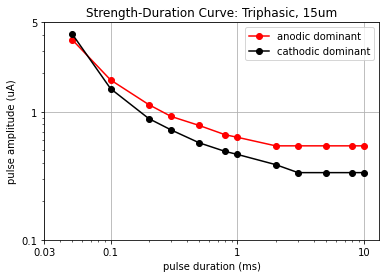

In [14]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.loglog(durations, anodic, 'ro-', label='anodic dominant')
ax.loglog(durations, cathodic, 'ko-', label='cathodic dominant')

# ax.scatter(durations, anodic, c='r')
# ax.scatter(durations, cathodic, c='k')

# ax.plot(x_fit,y_fit_a, alpha=0.8, c='r', label='anodic')
# ax.plot(x_fit,y_fit_c, alpha=0.8, c='k', label='cathodic')

# ax.plot(x_fit,y_fit_a_w, alpha=0.8, label='anodic - weiss', c='r', linestyle='--')
# ax.plot(x_fit,y_fit_c_w, alpha=0.8, label='cathodic -weiss', c='k', linestyle='--')

ax.set_xscale('log', base=10)
ax.set_yscale('log', base=10)
ax.set_xticks([0.03, 0.1, 1, 10])
ax.set_xticklabels(['0.03', '0.1', '1', '10'])
ax.set_yticks([0.1, 1, 5])
ax.set_yticklabels(['0.1','1', '5'])
ax.set_ylabel('pulse amplitude (uA)')
ax.set_xlabel('pulse duration (ms)')
ax.set_title('Strength-Duration Curve: Triphasic, 15um')
ax.legend()
ax.grid()

### probe into exactly when the spike is initiating 

Triphasic, 15um, PW =  0.05 ms
Cathodic threshold:  1.4707874962331262 uA
Anodic threshold:  2.0547379388994624 uA


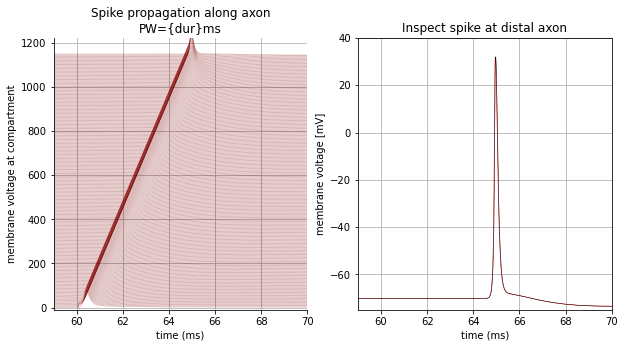

Triphasic, 15um, PW =  1 ms
Cathodic threshold:  0.3996432826818801 uA
Anodic threshold:  0.5871333149465792 uA


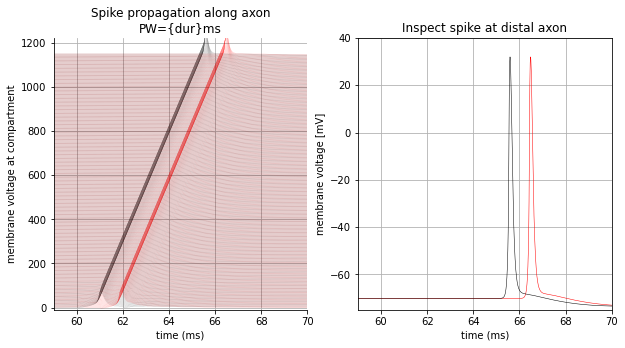

In [6]:
# load in S-D data pickle files 
durations = [0.05,1]# [0.05, 0.1, 0.2, 1, 2, 3, 5]
electrode = [-100, 0, 59]

for dur in durations: 
    filename_c = '../../data/strength_duration/triphasic/15um/cathodic_'+\
                str(dur)+'ms_'+\
                str(electrode[0])+'_'+\
                str(electrode[1])+'_'+\
                str(electrode[2])+'.pkl'

    filename_a = '../../data/strength_duration/triphasic/15um/anodic_'+\
                str(dur)+'ms_'+\
                str(electrode[0])+'_'+\
                str(electrode[1])+'_'+\
                str(electrode[2])+'.pkl'
    
    data_c = decompress_pickle(filename_c)
    data_a = decompress_pickle(filename_a)

    cathodic_thr = data_c[0]
    anodic_thr = data_a[0]
    t = data_c[1]

    cathodic_voltages = data_c[2]
    anodic_voltages = data_a[2]

    # Print out thresholds
    print('Triphasic, 15um, PW = ', str(dur), 'ms')
    print('Cathodic threshold: ', cathodic_thr, 'uA')
    print('Anodic threshold: ', anodic_thr, 'uA')

    # Example of plotting voltage traces at all axonal segments, tracking spike
    #  propagation along the membrane, expanding across space
    fig, (ax,ax2) = plt.subplots(1,2,figsize=(10,5))
    ax.grid()
    ax.spines["right"].set_visible(False)
    ax.spines["top"].set_visible(False)

    offset = -1*-70
    offset_step = 2
    for i in range(576):
        ax.plot(t,cathodic_voltages[i]+offset,'r',linewidth=0.1, alpha=0.5)
        ax.plot(t,anodic_voltages[i]+offset,'k',linewidth=0.1, alpha=0.5)  

        offset += offset_step

    ax.set_title('Spike propagation along axon\nPW={dur}ms')
    ax.set_xlabel('time (ms)')
    ax.set_ylabel('membrane voltage at compartment')

    ax.set_xlim(59,70)
    ax.set_ylim(-10,int(576)*offset_step+70)

    ## Now, plot the spike just at the distal axon, noting timing difference
    ax2.plot(t,cathodic_voltages[-1],'r',linewidth=0.5)
    ax2.plot(t,anodic_voltages[-1],'k',linewidth=0.5)

    ax2.set_title('Inspect spike at distal axon')
    ax2.set_xlabel('time (ms)')
    ax2.set_ylabel('membrane voltage [mV]')

    ax2.grid()
    ax2.set_xlim(59,70)
    ax2.set_ylim(-75,40)

    plt.show()
    

## Let's plot monophasic and biphasic on top of one another

In [19]:
# load in S-D data pickle files 
# durations_bi = [0.03,0.04,0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1, 2, 3, 5, 8, 10]
durations_bi = [0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1, 2, 3, 5, 8, 10]
durations = [0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1, 2, 3, 5, 8, 10]
# electrode = [-200, 0, 59]
electrode = [-65, 0, 59]

anodic_mono = []
cathodic_mono = []
anodic_bi = []
cathodic_bi = []
anodic_tri = []
cathodic_tri = []

# for dur in durations_bi: 
#     filename_c = '/Volumes/Lab/Users/vilkhu/workspace/rgc_simulaton/src/data/strength_duration/biphasic/15um/cathodic_'+\
#                 str(dur)+'ms_'+\
#                 str(electrode[0])+'_'+\
#                 str(electrode[1])+'_'+\
#                 str(electrode[2])+'.pkl'

#     filename_a = '/Volumes/Lab/Users/vilkhu/workspace/rgc_simulaton/src/data/strength_duration/biphasic/15um/anodic_'+\
#                 str(dur)+'ms_'+\
#                 str(electrode[0])+'_'+\
#                 str(electrode[1])+'_'+\
#                 str(electrode[2])+'.pkl'
    
#     data_c = decompress_pickle(filename_c)
#     data_a = decompress_pickle(filename_a)

#     cathodic_bi.append(data_c[0])
#     anodic_bi.append(data_a[0])

for dur in durations: 
    filename_c = '/Volumes/Lab/Users/vilkhu/workspace/rgc_simulaton/src/data/strength_duration/monophasic/15um/cathodic_'+\
                str(dur)+'ms_'+\
                str(electrode[0])+'_'+\
                str(electrode[1])+'_'+\
                str(electrode[2])+'.pkl'

    filename_a = '/Volumes/Lab/Users/vilkhu/workspace/rgc_simulaton/src/data/strength_duration/monophasic/15um/anodic_'+\
                str(dur)+'ms_'+\
                str(electrode[0])+'_'+\
                str(electrode[1])+'_'+\
                str(electrode[2])+'.pkl'
    
    data_c = decompress_pickle(filename_c)
    data_a = decompress_pickle(filename_a)

    cathodic_mono.append(data_c[0])
    anodic_mono.append(data_a[0])

    filename_c = '/Volumes/Lab/Users/vilkhu/workspace/rgc_simulaton/src/data/strength_duration/triphasic/15um/cathodic_'+\
                str(dur)+'ms_'+\
                str(electrode[0])+'_'+\
                str(electrode[1])+'_'+\
                str(electrode[2])+'.pkl'

    filename_a = '/Volumes/Lab/Users/vilkhu/workspace/rgc_simulaton/src/data/strength_duration/triphasic/15um/anodic_'+\
                str(dur)+'ms_'+\
                str(electrode[0])+'_'+\
                str(electrode[1])+'_'+\
                str(electrode[2])+'.pkl'
    
    data_c = decompress_pickle(filename_c)
    data_a = decompress_pickle(filename_a)

    cathodic_tri.append(data_c[0])
    anodic_tri.append(data_a[0]*(2/3))

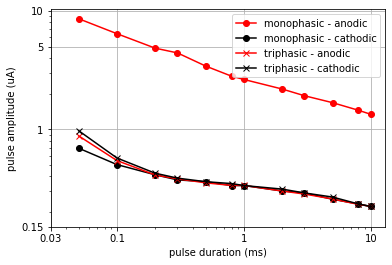

In [20]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.loglog(durations, anodic_mono, 'ro-', label='monophasic - anodic')
ax.loglog(durations, cathodic_mono, 'ko-', label='monophasic - cathodic')

ax.loglog(durations, anodic_tri, 'rx-', label='triphasic - anodic')
ax.loglog(durations, cathodic_tri, 'kx-', label='triphasic - cathodic')

# ax.loglog(durations_bi, anodic_bi, 'rs--', label='biphasic - anodic-first')
# ax.loglog(durations_bi, cathodic_bi, 'ks--', label='biphasic - cathodic-first')

ax.set_xscale('log', base=10)
ax.set_yscale('log', base=10)
ax.set_xticks([0.03, 0.1, 1, 10])
ax.set_xticklabels(['0.03', '0.1', '1', '10'])
ax.set_yticks([0.15, 1, 5, 10])
ax.set_yticklabels(['0.15','1', '5', '10'])
ax.set_ylabel('pulse amplitude (uA)')
ax.set_xlabel('pulse duration (ms)')
# ax.set_title('Extracellular Stimulation Strength-Duration Curve')
ax.legend()
ax.grid()

# save as pdf
plt.savefig('strength_duration_socb.pdf', format='pdf')

In [7]:
currents = np.logspace(0,4,25,base=2)-1
print(currents)

[ 0.          0.12246205  0.25992105  0.41421356  0.58740105  0.78179744
  1.          1.2449241   1.5198421   1.82842712  2.1748021   2.56359487
  3.          3.48984819  4.0396842   4.65685425  5.34960421  6.12718975
  7.          7.97969639  9.0793684  10.3137085  11.69920842 13.25437949
 15.        ]


## Let's plot monophasic and triphasic on top of one another

In [11]:
# load in S-D data pickle files 
durations = [0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1, 2, 3, 5, 8, 10]
electrode = [-65, 0, 59]

anodic_mono = []
cathodic_mono = []
anodic_tri = []
cathodic_tri = []

for dur in durations: 
    filename_c = '/Volumes/Lab/Users/vilkhu/workspace/rgc_simulaton/src/data/strength_duration/monophasic/15um/cathodic_'+\
                str(dur)+'ms_'+\
                str(electrode[0])+'_'+\
                str(electrode[1])+'_'+\
                str(electrode[2])+'.pkl'

    filename_a = '/Volumes/Lab/Users/vilkhu/workspace/rgc_simulaton/src/data/strength_duration/monophasic/15um/anodic_'+\
                str(dur)+'ms_'+\
                str(electrode[0])+'_'+\
                str(electrode[1])+'_'+\
                str(electrode[2])+'.pkl'
    
    data_c = decompress_pickle(filename_c)
    data_a = decompress_pickle(filename_a)

    cathodic_mono.append(data_c[0])
    anodic_mono.append(data_a[0])

    filename_c = '/Volumes/Lab/Users/vilkhu/workspace/rgc_simulaton/src/data/strength_duration/triphasic/15um/cathodic_'+\
                str(dur)+'ms_'+\
                str(electrode[0])+'_'+\
                str(electrode[1])+'_'+\
                str(electrode[2])+'.pkl'

    filename_a = '/Volumes/Lab/Users/vilkhu/workspace/rgc_simulaton/src/data/strength_duration/triphasic/15um/anodic_'+\
                str(dur)+'ms_'+\
                str(electrode[0])+'_'+\
                str(electrode[1])+'_'+\
                str(electrode[2])+'.pkl'
    
    data_c = decompress_pickle(filename_c)
    data_a = decompress_pickle(filename_a)

    cathodic_tri.append(data_c[0])
    anodic_tri.append(data_a[0]*(2/3))

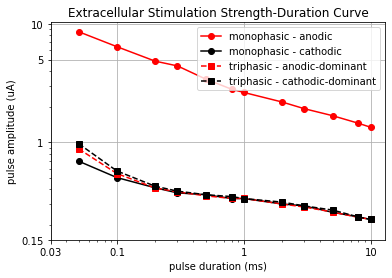

In [12]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.loglog(durations, anodic_mono, 'ro-', label='monophasic - anodic')
ax.loglog(durations, cathodic_mono, 'ko-', label='monophasic - cathodic')

ax.loglog(durations, anodic_tri, 'rs--', label='triphasic - anodic-dominant')
ax.loglog(durations, cathodic_tri, 'ks--', label='triphasic - cathodic-dominant')

ax.set_xscale('log', base=10)
ax.set_yscale('log', base=10)
ax.set_xticks([0.03, 0.1, 1, 10])
ax.set_xticklabels(['0.03', '0.1', '1', '10'])
ax.set_yticks([0.15, 1, 5, 10])
ax.set_yticklabels(['0.15','1', '5', '10'])
ax.set_ylabel('pulse amplitude (uA)')
ax.set_xlabel('pulse duration (ms)')
ax.set_title('Extracellular Stimulation Strength-Duration Curve')
ax.legend()
ax.grid()

### Track spike latency at thereshold for various pulse durations 

In [23]:
# Load in triphasic data 
# load in S-D data pickle files 
durations = [0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1, 2, 3, 5, 8, 10]
# durations = [0.05, 1]
electrode = [-200, 0, 59]

time_diff = []

for dur in durations: 
    filename_c = '../../data/strength_duration/triphasic/15um/cathodic_'+\
                str(dur)+'ms_'+\
                str(electrode[0])+'_'+\
                str(electrode[1])+'_'+\
                str(electrode[2])+'.pkl'

    filename_a = '../../data/strength_duration/triphasic/15um/anodic_'+\
                str(dur)+'ms_'+\
                str(electrode[0])+'_'+\
                str(electrode[1])+'_'+\
                str(electrode[2])+'.pkl'
    
    data_c = decompress_pickle(filename_c)
    data_a = decompress_pickle(filename_a)

    t_vec = np.array(data_c[1])

    vRec_cathodic = np.array(data_c[2])
    vRec_anodic = np.array(data_a[2])

    # Extract spike time at distal axon and compute spike timing difference 
    time_cathodic = t_vec[np.argmax(vRec_cathodic[-1])]
    time_anodic = t_vec[np.argmax(vRec_anodic[-1])]
    time_diff.append(round(time_cathodic-time_anodic,3))
    

In [24]:
print(time_diff)

[0.7, -0.035, 0.18, 0.375, 0.58, 0.855, 1.07, 1.99, 3.01, 4.275, 8.795, 8.795]


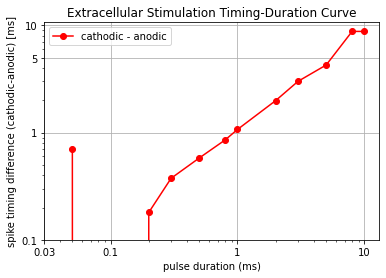

In [25]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.loglog(durations, time_diff, 'ro-', label='cathodic - anodic')
# ax.plot(durations, time_diff, 'ko-', label='cathodic - anodic')


ax.set_xscale('log', base=10)
ax.set_yscale('log', base=10)
ax.set_xticks([0.03, 0.1, 1, 10])
ax.set_xticklabels(['0.03', '0.1', '1', '10'])
ax.set_yticks([0.1, 1, 5, 10])
ax.set_yticklabels(['0.1','1', '5', '10'])
# ax.set_xticks([0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10])
# ax.set_xticklabels(['0.05', '0.1', '0.2', '0.5', '1', '2', '5', '10'])
# ax.set_yticks([0.05, 0.1, 0.2, 0.5, 1, 2, 5, 10])
# ax.set_yticklabels(['0.05', '0.1', '0.2', '0.5', '1', '2', '5', '10'])
ax.set_ylabel('spike timing difference (cathodic-anodic) [ms]')
ax.set_xlabel('pulse duration (ms)')
ax.set_title('Extracellular Stimulation Timing-Duration Curve')
ax.legend()
ax.grid()

## Plot SD curves for Paul's 10us biphasic pulses

### Axonal compartments 

In [3]:
# load in S-D data pickle files 
durations = [0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,0.1,0.2,0.3,0.4,0.5]
electrode = [-1000, 0, 42]

anodic_axon = []
cathodic_axon = []

for dur in durations: 
    filename_a = '/Volumes/Lab/Users/vilkhu/data-backup/strength_duration/biphasic/paul_0.001ms/anodicFirst_axonal/'+\
                str(dur)+'ms_'+\
                str(electrode[0])+'_'+\
                str(electrode[1])+'_'+\
                str(electrode[2])+'.pkl'

    # filename_c = '/Volumes/Lab/Users/vilkhu/data-backup/strength_duration/biphasic/10um/cathodicFirst_axonal/'+\
    #             str(dur)+'ms_'+\
    #             str(electrode[0])+'_'+\
    #             str(electrode[1])+'_'+\
    #             str(electrode[2])+'.pkl'
    
    data_a = decompress_pickle(filename_a)
    # data_c = decompress_pickle(filename_c)

    anodic_axon.append(data_a[0])
    # cathodic_axon.append(data_c[0])

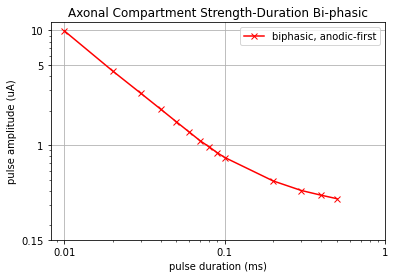

In [4]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.loglog(durations, anodic_axon, 'rx-', label='biphasic, anodic-first')
# ax.loglog(durations, cathodic_axon, 'kx-', label='biphasic, cathodic-first')

ax.set_xscale('log', base=10)
ax.set_yscale('log', base=10)
ax.set_xticks([0.01,0.1,1])
ax.set_xticklabels(['0.01','0.1','1'])
ax.set_yticks([0.15, 1, 5, 10])
ax.set_yticklabels(['0.15','1', '5', '10'])
ax.set_ylabel('pulse amplitude (uA)')
ax.set_xlabel('pulse duration (ms)')
ax.set_title('Axonal Compartment Strength-Duration Bi-phasic')
ax.legend()
ax.grid()

# save as pdf
# plt.savefig('strength_duration_axon.pdf', format='pdf')

### SOCB compartment

In [5]:
# load in S-D data pickle files 
durations = [0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,0.1,0.2,0.3,0.4,0.5]
electrode = [-60, 0, 42]

anodic_socb = []
cathodic_socb = []

for dur in durations: 
    filename_a = '/Volumes/Lab/Users/vilkhu/data-backup/strength_duration/biphasic/paul_0.001ms/anodicFirst_socb/'+\
                str(dur)+'ms_'+\
                str(electrode[0])+'_'+\
                str(electrode[1])+'_'+\
                str(electrode[2])+'.pkl'

    # filename_c = '/Volumes/Lab/Users/vilkhu/data-backup/strength_duration/biphasic/10um/cathodicFirst_somatic/'+\
    #             str(dur)+'ms_'+\
    #             str(electrode[0])+'_'+\
    #             str(electrode[1])+'_'+\
    #             str(electrode[2])+'.pkl'
    
    data_a = decompress_pickle(filename_a)
    # data_c = decompress_pickle(filename_c)

    anodic_socb.append(data_a[0])
    # cathodic_socb.append(data_c[0])

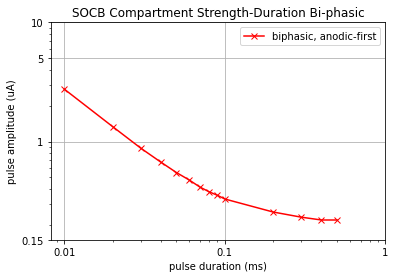

In [6]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.loglog(durations, anodic_socb, 'rx-', label='biphasic, anodic-first')
# ax.loglog(durations, cathodic_socb, 'kx-', label='biphasic, cathodic-first')

# ax.loglog(durations_bi, anodic_bi, 'rs--', label='biphasic - anodic-first')
# ax.loglog(durations_bi, cathodic_bi, 'ks--', label='biphasic - cathodic-first')

ax.set_xscale('log', base=10)
ax.set_yscale('log', base=10)
ax.set_xticks([0.01,0.1,1])
ax.set_xticklabels(['0.01','0.1','1'])
ax.set_yticks([0.15, 1, 5, 10])
ax.set_yticklabels(['0.15','1', '5', '10'])
ax.set_ylabel('pulse amplitude (uA)')
ax.set_xlabel('pulse duration (ms)')
ax.set_title('SOCB Compartment Strength-Duration Bi-phasic')
ax.legend()
ax.grid()

# save as pdf
# plt.savefig('strength_duration_axon.pdf', format='pdf')

### Plot the threshold ratio

In [7]:
print(np.array(anodic_axon))
print(np.array(anodic_socb))
print(np.array(anodic_axon)/np.array(anodic_socb))

[9.94124607 4.44355289 2.83409721 2.05509077 1.59801111 1.30417419
 1.09740006 0.96680587 0.85797738 0.78179744 0.4886234  0.4031143
 0.36646755 0.34203638]
[2.75653308 1.33682273 0.87974308 0.67185717 0.54970132 0.47640781
 0.41532989 0.37868313 0.35425196 0.32982079 0.25652728 0.23209611
 0.21988053 0.21988053]
[3.6064309  3.32396568 3.22150555 3.05882091 2.90705342 2.73751637
 2.64223714 2.55307349 2.42194107 2.37037037 1.9047619  1.73684211
 1.66666667 1.55555556]


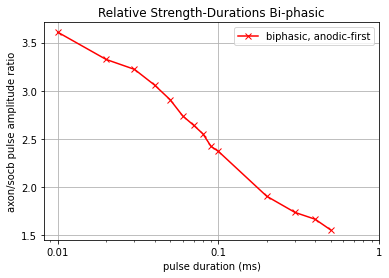

In [10]:
# Plot the ratio between anodic_axon and anodic_socb for the same pulse duration points
fig = plt.figure()
ax = fig.add_subplot(111)

ratio_anodic = np.array(anodic_axon)/np.array(anodic_socb)
# ratio_cathodic = np.array(cathodic_axon)/np.array(cathodic_socb)
ax.loglog(durations, ratio_anodic, 'rx-', label='biphasic, anodic-first')
# ax.loglog(durations, ratio_cathodic, 'kx-', label='biphasic, cathodic-first')
# ax.loglog(durations, cathodic, 'kx-', label='triphasic - cathodic')


ax.set_xscale('log', base=10)
ax.set_yscale('linear')
ax.set_xticks([0.01,0.1,1])
ax.set_xticklabels(['0.01','0.1','1'])
# ax.set_yticks([0.15, 1, 5, 10])
# ax.set_yticklabels(['0.15','1', '5', '10'])
ax.set_ylabel('axon/socb pulse amplitude ratio')
ax.set_xlabel('pulse duration (ms)')
ax.set_title('Relative Strength-Durations Bi-phasic')
ax.legend()
ax.grid()
